# Missing Values
## Three Approaches
1. Drop Columns with missing values.
2. Imputation: Filling missing values with some number like mean.  
It is better than droping the column.
3. An Extension to Imputation:  Impute the missing value.  
It includes an additional columns which shows the which values was missing 
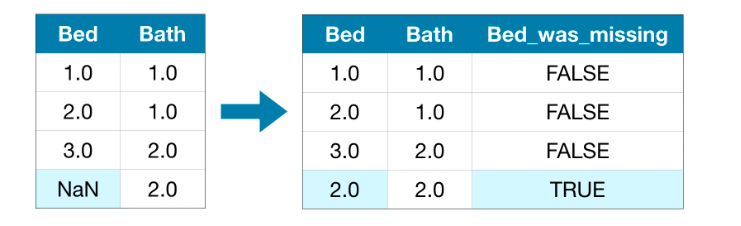


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv(r"C:\Kaggle\Intermediate_ML\melb_data.csv")

y = data.Price

melb_predcitors = data.drop(['Price'], axis=1)
X = melb_predcitors.select_dtypes(exclude=['object'])

X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=0)

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

def score_dataset(X_train, X_valid, y_train, y_valid):
    model = RandomForestRegressor(n_estimators=10, random_state=0)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_valid)
    return mean_absolute_error(y_valid, preds)

- List Comprehension Fromat:
[expression for item in iterable if condition]  
expression get add to the list.

## Score from Appraoch 1

In [3]:
cols_with_missing = [col for col in X_train.columns if X_train[col].isnull().any()]
# any() method return True if at least one value is True

reduced_X_train = X_train.drop(cols_with_missing, axis=1)
reduced_X_valid = X_valid.drop(cols_with_missing, axis=1)

print(f"MAE from Approach 1 (Drop columns with missing values): {score_dataset(reduced_X_train, reduced_X_valid, y_train, y_valid)}")

MAE from Approach 1 (Drop columns with missing values): 183550.22137772635


## Score from Approach 2

In [4]:
from sklearn.impute import SimpleImputer

# SimpleImputer Core methods fit, transform, fit_transform
# Returns NumPy array.
my_imputer = SimpleImputer()
imputed_X_train = pd.DataFrame(my_imputer.fit_transform(X_train))
imputed_X_valid = pd.DataFrame(my_imputer.transform(X_valid))

imputed_X_train.columns = X_train.columns
imputed_X_valid.columns = X_valid.columns

print(f"MAE from Approach 2 (Imputation): {score_dataset(imputed_X_train, imputed_X_valid, y_train, y_valid)}")

MAE from Approach 2 (Imputation): 178166.46269899711


- Approach 2 has lower mae than appraoch 1 so, it's better on this dataset.

## Score from Approach 3 (An Extension to Imputation)

In [5]:
X_train_plus = X_train.copy()
X_valid_plus = X_valid.copy()

for cols in cols_with_missing:
    X_train_plus[cols + '_was_missing'] = X_train_plus[cols].isnull()
    X_valid_plus[cols + '_was_missing'] = X_valid_plus[cols].isnull()

my_imputer = SimpleImputer()
imputed_X_train_plus = pd.DataFrame(my_imputer.fit_transform(X_train_plus))
imputed_X_valid_plus = pd.DataFrame(my_imputer.transform(X_valid_plus))

imputed_X_train_plus.columns = X_train_plus.columns
imputed_X_valid_plus.columns = X_valid_plus.columns

print("MAE from Approach 3 (An Extension to Imputation):")
print(score_dataset(imputed_X_train_plus, imputed_X_valid_plus, y_train, y_valid))

MAE from Approach 3 (An Extension to Imputation):
178927.503183954


- Approach 3 performed slightly worse than Approach 2.

In [6]:
print(X_train.shape)
print(type(X_train.shape))
missing_val_count_by_column = X_train.isnull().sum()
print(type(missing_val_count_by_column))
print(missing_val_count_by_column[missing_val_count_by_column > 0])

(10864, 12)
<class 'tuple'>
<class 'pandas.core.series.Series'>
Car               49
BuildingArea    5156
YearBuilt       4307
dtype: int64


# Categorical Variables
## Three Approaches:
1. Drop Categorical Column
2. Ordinal Encoding assigns each unique value to a different integer.
3. One-hot encoding creates a new columns indicating the presence or absence of values.
- it does not have an order.
- Example:  
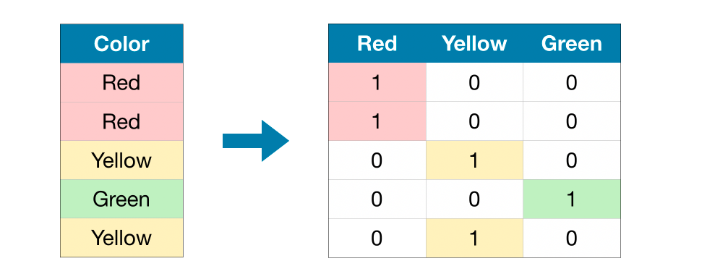

In [8]:
data = pd.read_csv(r"C:\Kaggle\Intermediate_ML\melb_data.csv")

y = data.Price
X = data.drop(['Price'], axis=1)

X_train_full, X_valid_full, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=0)

cols_with_missing = [col for col in X_train_full.columns if X_train_full[col].isnull().any()]
X_train_full.drop(cols_with_missing, axis=1, inplace=True)
X_valid_full.drop(cols_with_missing, axis=1, inplace=True)

# Cardinality means number of unique values in a column.
low_cardinality_cols = [cname for cname in X_train_full.columns if X_train_full[cname].nunique() < 10
                         and X_train_full[cname].dtype == 'object']
# nunique() count no. of unique values in a column.

numerical_cols = [cname for cname in X_train_full.columns if X_train_full[cname].dtype in ['int64', 'float64']]

my_cols = low_cardinality_cols + numerical_cols
X_train = X_train_full[my_cols].copy()
X_valid = X_valid_full[my_cols].copy()

In [9]:
X_train.head()

,Type,Method,Regionname,Rooms,Distance,Postcode,Bedroom2,Bathroom,Landsize,Lattitude,Longtitude,Propertycount
12167,u,S,Southern Metropolitan,1,5.0,3182.0,1.0,1.0,0.0,-37.85984,144.9867,13240.0
6524,h,SA,Western Metropolitan,2,8.0,3016.0,2.0,2.0,193.0,-37.85800,144.9005,6380.0
8413,h,S,Western Metropolitan,3,12.6,3020.0,3.0,1.0,555.0,-37.79880,144.8220,3755.0
2919,u,SP,Northern Metropolitan,3,13.0,3046.0,3.0,1.0,265.0,-37.70830,144.9158,8870.0
6043,h,S,Western Metropolitan,3,13.3,3020.0,3.0,1.0,673.0,-37.76230,144.8272,4217.0


In [13]:
# Get list of Catregorical variables
s = X_train.dtypes == 'object'
object_cols = list(s[s].index)
# s[s] is boolean indexing operation
# means selecting element s where values in s is True
print(type(s[s].index))
print("Categorical Variables:")
print(object_cols)

<class 'pandas.core.indexes.base.Index'>
Categorical Variables:
['Type', 'Method', 'Regionname']


In [14]:
def score_dataset(X_train, X_valid, y_train, y_valid):
    model = RandomForestRegressor(n_estimators=100, random_state=0)
    model.fit(X_train, y_train)

    preds = model.predict(X_valid)
    return mean_absolute_error(y_valid, preds)

### Score from Approach 1(Drop Categorical Variables)

In [15]:
drop_X_train = X_train.select_dtypes(exclude=['object'])
drop_X_valid = X_valid.select_dtypes(exclude=['object'])
# select_dtypes(include= / exclude=) is a pandas DataFrame method used to return a DataFrame
# containing columns selected based on their datatype.

print("MAE from Approach 1 (Drop categorical variables):")
print(score_dataset(drop_X_train, drop_X_valid, y_train, y_valid))

MAE from Approach 1 (Drop categorical variables):
175703.48185157913
